In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
 
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.evaluators import CompareModels, ModelEvaluator
from utils.plot_function import *
#from scripts.modelClassGPU import ConfiModel
#from scripts.modelClassGPU_old import ConfiModel as old_model
#from scripts.experiments import Experiment 
plot_path = 'M:\\1confiProj\\Analysis\\output'

device is : cpu


## Model simulation

In [29]:
m_label = 'with_dn'
m_lst= [2]
ev=ModelEvaluator(m_label)
df_sim_lst = []

for m_id in m_lst:
    df_m_sim = ev.get_allsub_pred_data(m_id=m_id, save_csv=False)
    df_sim_lst.append(df_m_sim)

df_sim = pd.concat(df_sim_lst, ignore_index=True)

df_beh = ev.dh.get_allsub_beh_data()

Model 2 subjects: 100%|██████████| 8/8 [00:02<00:00,  2.75subject/s]


In [15]:
df_sim

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,...,bias,flipBias,abs_delta_VA,bias_abs,bias_abs_rel,bias_rel,flipBias_abs,bias_abs_zscore,CISize_zscore,m_id
0,-10.0,-10.0,1.0,1.0,2.020095,8.792318,2.0,65.0,2,0.0,...,10.137341,10.137341,0.0,12.020095,inf,inf,12.020095,2.199893,1.278253,2
1,-10.0,-10.0,1.0,1.0,5.746748,7.036171,2.0,66.0,2,0.0,...,13.863995,13.863995,0.0,15.746748,inf,inf,15.746748,2.883379,0.465363,2
2,-10.0,-10.0,1.0,1.0,-11.408154,6.075074,1.0,66.0,2,0.0,...,-3.290908,-3.290908,0.0,-1.408154,-inf,-inf,-1.408154,-0.262911,0.020488,2
3,-10.0,-10.0,1.0,1.0,-9.585236,3.348578,1.0,65.0,2,0.0,...,-1.467989,-1.467989,0.0,0.414764,inf,-inf,0.414764,0.071421,-1.241558,2
4,-10.0,-10.0,1.0,1.0,-6.641954,5.384919,1.0,65.0,2,0.0,...,1.475292,1.475292,0.0,3.358046,inf,inf,3.358046,0.611233,-0.298972,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797270,10.0,10.0,2.0,0.0,7.805184,8.749200,1.0,76.0,25,0.0,...,2.947385,2.947385,0.0,-2.194816,-inf,inf,-2.194816,-0.284467,-0.351961,2
797271,10.0,10.0,2.0,0.0,6.350046,9.710477,1.0,77.0,25,0.0,...,1.492247,1.492247,0.0,-3.649954,-inf,inf,-3.649954,-0.469719,0.170478,2
797272,10.0,10.0,2.0,0.0,-1.125969,11.769429,2.0,77.0,25,0.0,...,-5.983768,-5.983768,0.0,-11.125969,-inf,-inf,-11.125969,-1.421482,1.289488,2
797273,10.0,10.0,2.0,0.0,5.650061,11.229259,1.0,77.0,25,0.0,...,0.792262,0.792262,0.0,-4.349939,-inf,inf,-4.349939,-0.558833,0.995913,2


In [4]:
df_beh

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,...,mean,bias,flipBias,abs_delta_VA,bias_abs,bias_abs_rel,bias_rel,flipBias_abs,bias_abs_zscore,CISize_zscore
0,5.0,-10.0,1.0,1.0,-4.93,4.69,1.0,20.0,2,-15.0,...,5.146216,-10.076216,10.076216,15.0,-9.93,0.662000,0.671748,9.93,-1.798937,-0.331626
1,-10.0,10.0,1.0,1.0,4.93,4.46,2.0,41.0,2,20.0,...,-8.312162,13.242162,13.242162,20.0,14.93,0.746500,0.662108,14.93,2.319995,-0.460572
2,-5.0,-10.0,1.0,1.0,-5.94,5.56,1.0,39.0,2,-5.0,...,-4.934054,-1.005946,1.005946,5.0,-0.94,0.188000,0.201189,0.94,-0.309428,0.156129
3,-5.0,5.0,1.0,1.0,4.38,2.01,1.0,78.0,2,10.0,...,-4.934054,9.314054,9.314054,10.0,9.38,0.938000,0.931405,9.38,1.400442,-1.834135
4,-5.0,-5.0,1.0,1.0,-3.82,2.91,1.0,88.0,2,0.0,...,-4.934054,1.114054,1.114054,0.0,1.18,inf,inf,1.18,0.041825,-1.329561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19427,5.0,-10.0,2.0,0.0,-6.94,9.95,2.0,84.0,25,-15.0,...,-7.918333,0.978333,-0.978333,15.0,-11.94,0.796000,-0.065222,11.94,-1.326974,0.045977
19428,-10.0,5.0,2.0,0.0,5.83,8.22,2.0,100.0,25,15.0,...,5.925833,-0.095833,-0.095833,15.0,15.83,1.055333,-0.006389,15.83,1.700414,-0.396073
19429,10.0,5.0,2.0,0.0,5.94,11.75,1.0,100.0,25,-5.0,...,5.925833,0.014167,-0.014167,5.0,-4.06,0.812000,-0.002833,4.06,-0.467924,0.505913
19430,-5.0,-5.0,2.0,0.0,-5.60,11.77,1.0,100.0,25,0.0,...,-5.005833,-0.594167,-0.594167,0.0,-0.60,-inf,-inf,-0.60,-0.090727,0.511023


## Plot CI


In [3]:
def plot_CI_size_by_condition(df, m_id=None, axs=None, Modality='A', loc_var = 'AudLoc'):
    
    if m_id is not None:
        #model simulation data
        df = df.loc[(df.m_id == m_id) & (df.Modality == Modality)].copy()
    else:
        #beh data
        df = df.loc[df.Modality == Modality].copy()
    df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', loc_var]).CISize.mean().reset_index()
    palette = sns.color_palette("viridis", as_cmap=False)

    sns.lineplot(
        data=df_plot[df_plot.VisRelLabel == 'High'],
        x=loc_var,
        y='CISize',
        hue='abs_delta_VA',
        palette=palette,
        linewidth=2.5,
        ax = axs[0],
        legend = None,
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
    )
    sns.lineplot(
        data=df_plot[df_plot.VisRelLabel == 'Low'],
        x=loc_var,
        y='CISize',
        hue='abs_delta_VA',
        palette=palette,
        linewidth=2.5,
        ax = axs[1],
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
        #legend = None,
    )
    clean_axs(axs[0])
    clean_axs(axs[1])
    axs[0].set_xlabel('')
    axs[1].set_xlabel('')
    axs[1].legend(
        title='Absolute spatial disparity ($^\\circ$)',
        frameon=False,
        loc='lower center',
        ncol=5,
        bbox_to_anchor=(0, -0.5),
        fontsize=fontsize-2,
        title_fontsize=fontsize-2
    )
    # axs[0].set_title('High visual reliability', fontsize=fontsize)
    # axs[1].set_title('Low visual reliability', fontsize=fontsize)
    # axs[0].set_ylabel('Confidence interval', fontsize=fontsize)
    # axs[0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
    # axs[1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)


C:\Users\wenlou\AppData\Local\Temp\ipykernel_16928\1170273536.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_16928\1170273536.py:25: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_16928\1170273536.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_16928\1170273536.py:25: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


Text(0.02, 0.5, 'Confidence interval')

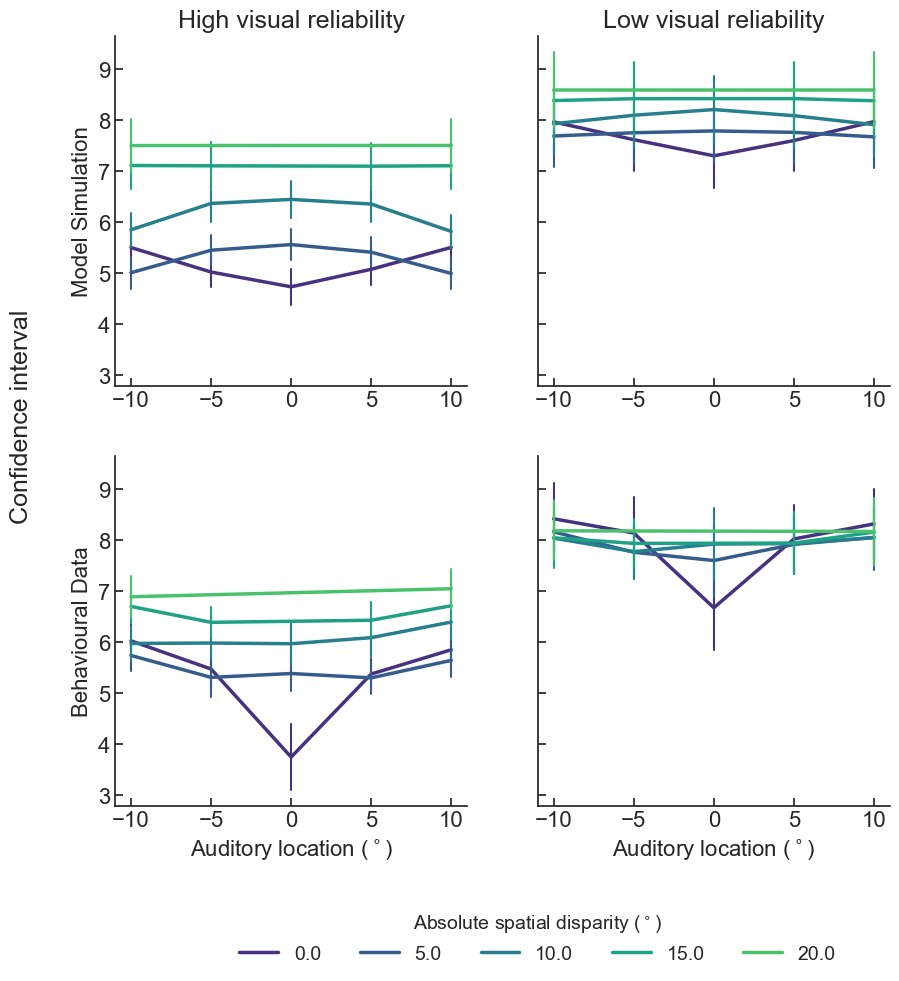

In [31]:
fig, axs = plt.subplots(figsize = (10, 10), nrows=2, ncols=2, sharey=True)

# axs[0,0].set_xlabel('')
# axs[0,1].set_xlabel('')
plot_CI_size_by_condition(df=df_sim, m_id=2, axs=axs[0,:]) 
#axs[0,1].legend('')
axs[0,1].get_legend().remove()
plot_CI_size_by_condition(df=df_beh, axs=axs[1,:]) 
axs[0,0].set_title('High visual reliability', fontsize=fontsize+2)
axs[0,1].set_title('Low visual reliability', fontsize=fontsize+2)
axs[0,0].set_ylabel('Model Simulation', fontsize=fontsize)
axs[1,0].set_ylabel('Behavioural Data', fontsize=fontsize)
axs[1,0].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
axs[1,1].set_xlabel('Auditory location ($^\\circ$)', fontsize=fontsize)
fig.supylabel('Confidence interval', fontsize=fontsize+2)

C:\Users\wenlou\AppData\Local\Temp\ipykernel_34340\1170273536.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_34340\1170273536.py:25: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_34340\1170273536.py:12: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
C:\Users\wenlou\AppData\Local\Temp\ipykernel_34340\1170273536.py:25: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


Text(0.5, 0.98, 'Visual modality')

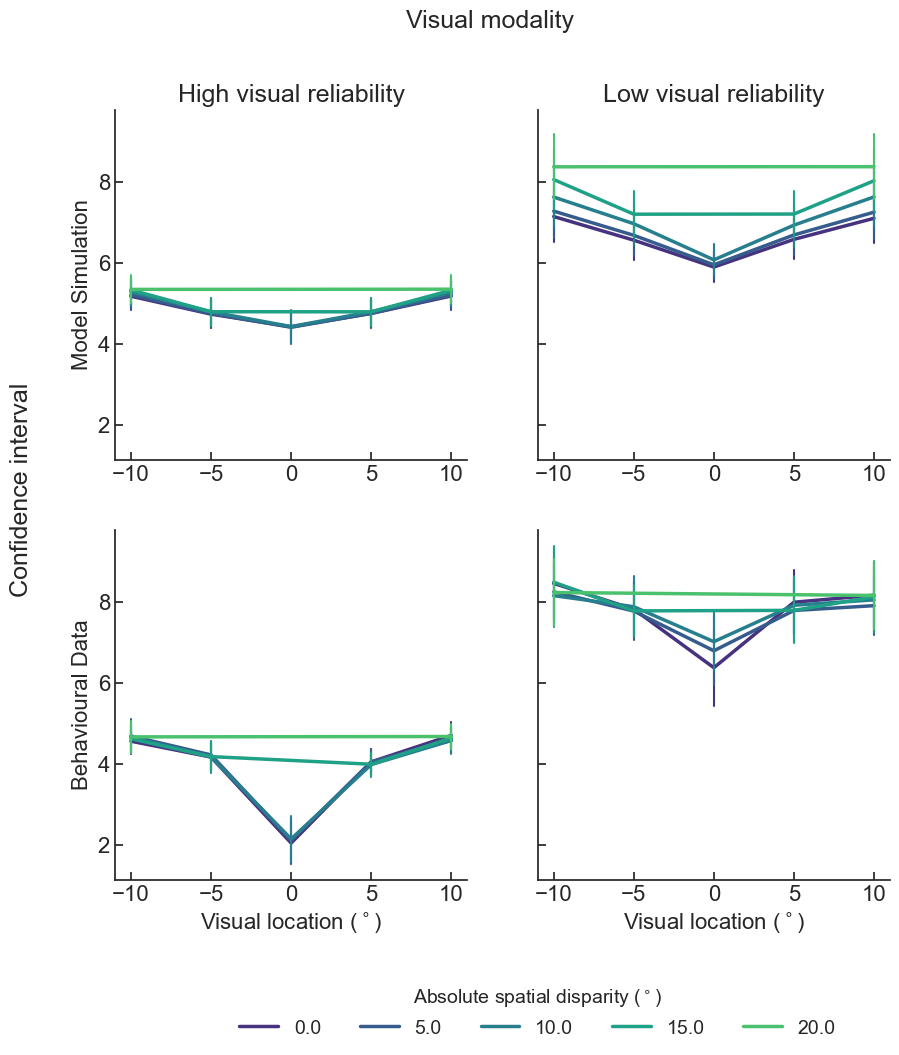

In [28]:
fig, axs = plt.subplots(figsize = (10, 10), nrows=2, ncols=2, sharey=True)

# axs[0,0].set_xlabel('')
# axs[0,1].set_xlabel('')
plot_CI_size_by_condition(df=df_sim, m_id=2, axs=axs[0,:], Modality='V', loc_var='VisLoc') 
#axs[0,1].legend('')
axs[0,1].get_legend().remove()
plot_CI_size_by_condition(df=df_beh, axs=axs[1,:], Modality='V', loc_var='VisLoc') 
axs[0,0].set_title('High visual reliability', fontsize=fontsize+2)
axs[0,1].set_title('Low visual reliability', fontsize=fontsize+2)
axs[0,0].set_ylabel('Model Simulation', fontsize=fontsize)
axs[1,0].set_ylabel('Behavioural Data', fontsize=fontsize)
axs[1,0].set_xlabel('Visual location ($^\\circ$)', fontsize=fontsize)
axs[1,1].set_xlabel('Visual location ($^\\circ$)', fontsize=fontsize)
fig.supylabel('Confidence interval', fontsize=fontsize+2)
fig.suptitle('Visual modality', fontsize=fontsize+2)
#fig.tight_layout()

## VENTRILOQUISM

### 1. three types of bias measurement

In [5]:
#define color scheme.
palette_beh= {'High': '#4C72B0', 'Low': '#DD8452'}
palette_mod= {'High': '#9FB3C8', 'Low': '#EBD38A'}

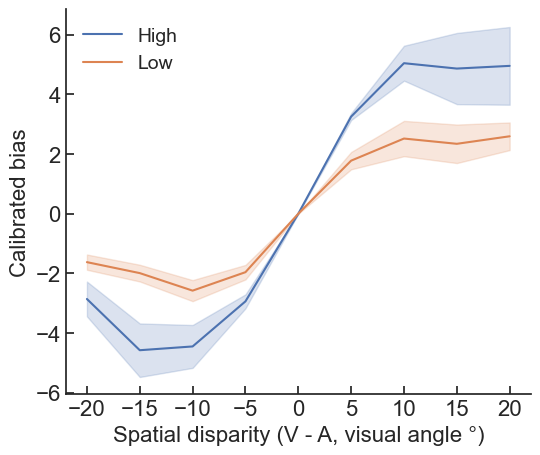

In [4]:
_,ax = plt.subplots(figsize = (6, 5), nrows=1, ncols=1)
plot_VE(df=df_beh, ax=ax, label='Calibrated bias')

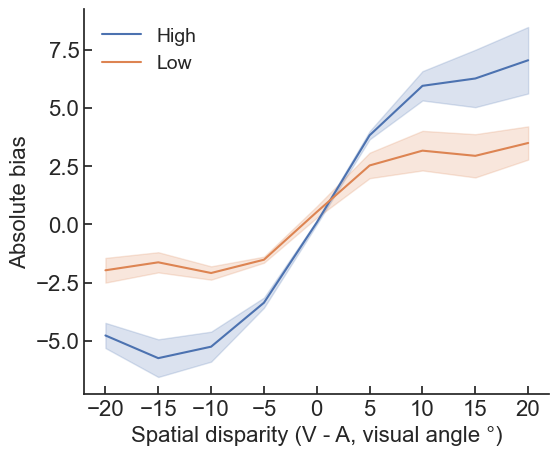

In [5]:
_,ax = plt.subplots(figsize = (6, 5), nrows=1, ncols=1)
plot_VE(df=df_beh, ax=ax, bias_var='bias_abs', label='Absolute bias')

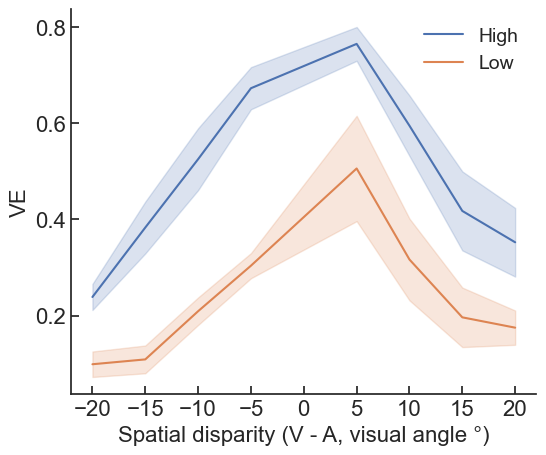

In [6]:
_,ax = plt.subplots(figsize = (6, 5), nrows=1, ncols=1)
plot_VE(df=df_beh, ax=ax, bias_var='bias_abs_rel', label='VE')

Text(0.5, 0.98, 'Visual blocks')

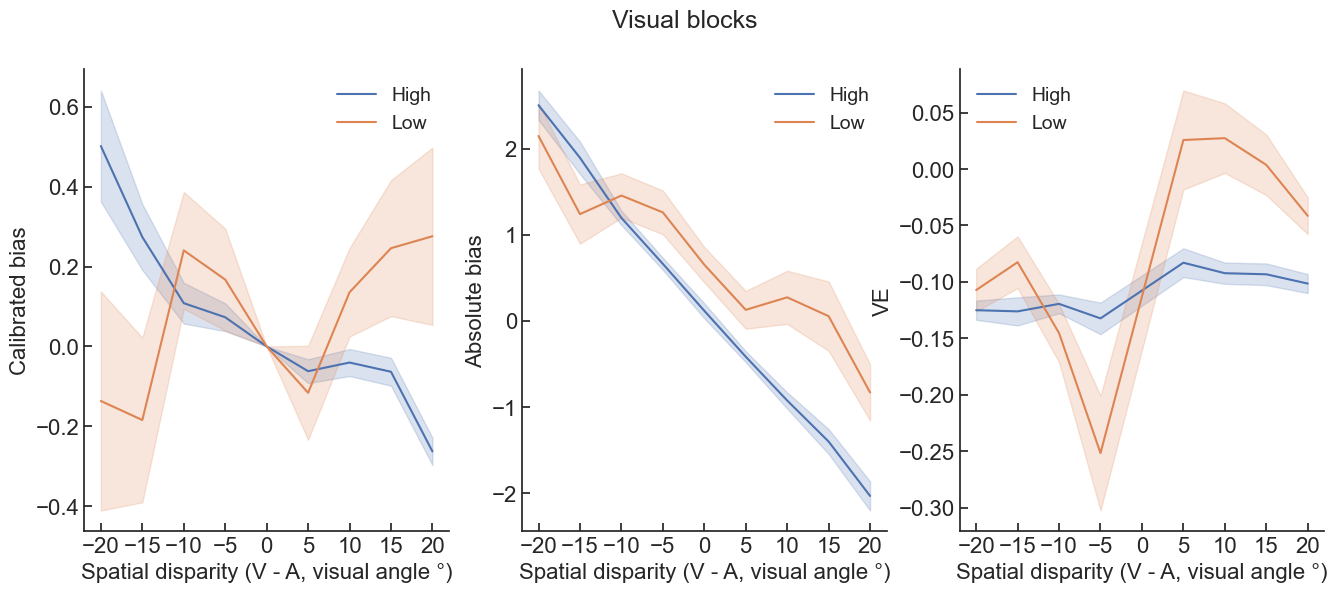

In [7]:
fig,axs = plt.subplots(figsize = (16, 6), nrows=1, ncols=3)
plot_VE(df=df_beh, ax=axs[0], label='Calibrated bias', trial_type='V')
plot_VE(df=df_beh, ax=axs[1], bias_var='bias_abs', label='Absolute bias', trial_type='V')
plot_VE(df=df_beh, ax=axs[2], bias_var='bias_abs_rel', label='VE', trial_type='V')
fig.suptitle('Visual blocks', fontsize=fontsize+2)

### 2. beh and model side by side

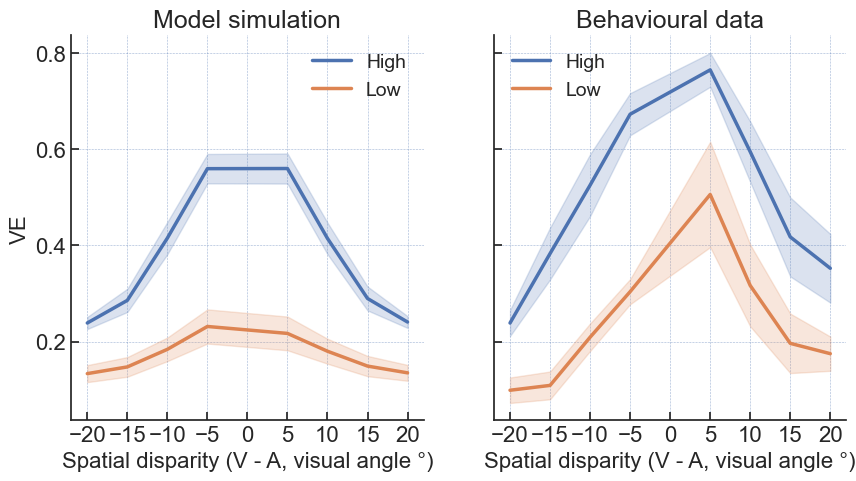

In [32]:
fig, axs = plt.subplots(figsize = (10, 5), nrows=1, ncols=2, sharey=True)
plot_VE(df=df_sim.loc[df_sim.m_id==2], bias_var='bias_abs_rel', label='VE', ax=axs[0])
plot_VE(df=df_beh, bias_var='bias_abs_rel', label='VE', ax=axs[1])
axs[0].set_title('Model simulation', fontsize=fontsize+2)
axs[1].set_title('Behavioural data', fontsize=fontsize+2)
axs[0].grid(color='b', linestyle=':', linewidth=0.4)
axs[1].grid(color='b', linestyle=':', linewidth=0.4)
plt.savefig(os.path.join(plot_path, 'VE_comparison.png'), dpi = 300)
# Change the way of plotting: the behaviour as dots on the model simulation line
# to-do, add plot type control in the plot_VE functions

### 3. Z-scored bias

In [86]:
#localization variability
def plot_variability(df,palette, ax, var_var='RespLoc', m_id=None, Modality='A', linestyle='-',marker='o'):
    
    if m_id is not None:
        #model simulation data
        df = df.loc[(df.m_id == m_id) & (df.Modality == Modality)].copy()
    else:
        #beh data
        df = df.loc[df.Modality == Modality].copy()
    df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc'])[var_var].var().reset_index()
    df_plot = df_plot.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA'])[var_var].mean().reset_index()
    #palette = sns.color_palette("viridis", as_cmap=False)

    sns.lineplot(
        data=df_plot,
        x='abs_delta_VA',
        y=var_var,
        hue='VisRelLabel',
        hue_order=['High','Low'],  
        palette=palette ,
        #palette=palette,
        linewidth=2.5,
        ax = ax,
        #legend = None,
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
        linestyle=linestyle,
        marker=marker ,
        #capsize=0.2 
        markersize=8
    )

    clean_axs(ax)
    #set x and y labels
    ax.set_xlabel('Absolute spatial disparity ($^\\circ$)', fontsize=fontsize)
    ax.set_ylabel('Localization variability', fontsize=fontsize)
    ax.legend(
        title='Visual reliability',
        frameon=False,
        loc='upper left',
        fontsize=fontsize-2,
        title_fontsize=fontsize-2
    )

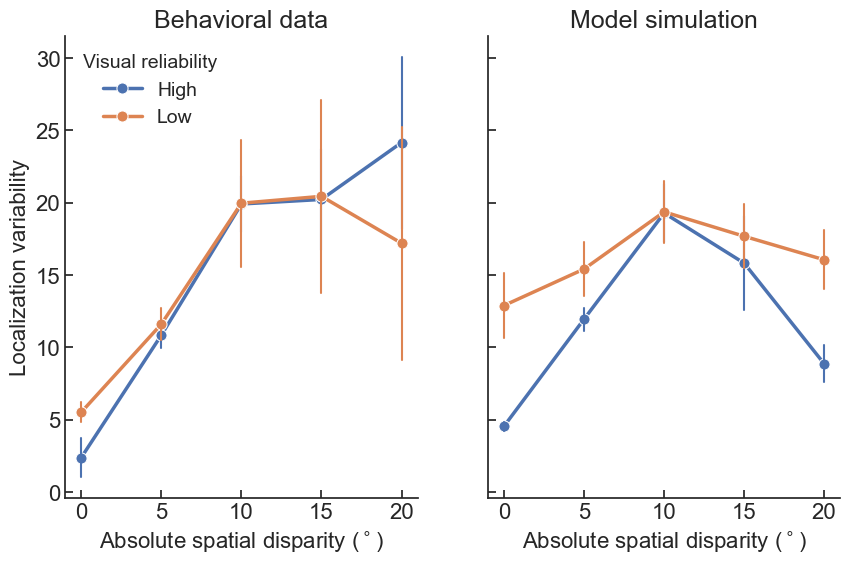

In [87]:
fig, axs = plt.subplots(figsize=(10,6), ncols = 2, nrows = 1, sharey=True)
plot_variability(df=df_beh,  ax=axs[0], Modality='A', palette= palette_beh)
plot_variability(df=df_sim, m_id=2, ax=axs[1], Modality='A', palette= palette_beh)
axs[0].set_title('Behavioral data', fontsize=fontsize+2)
axs[1].set_title('Model simulation', fontsize=fontsize+2)
axs[1].get_legend().remove()

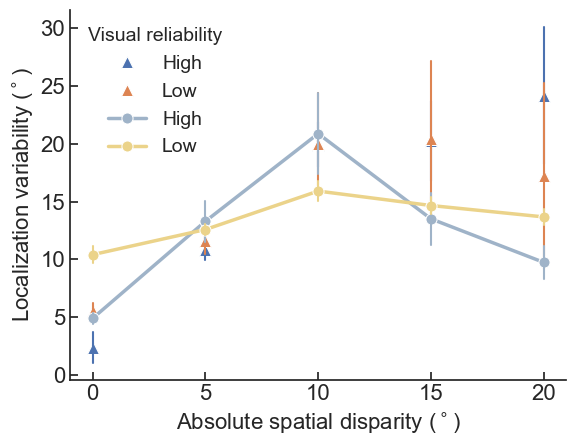

In [16]:
plot_variability(df=df_beh,  Modality='A',linestyle='',marker='^', palette= palette_beh)
plot_variability(df=df_sim, m_id=2, Modality='A', palette= palette_mod)

### 4. Z-scored confidence

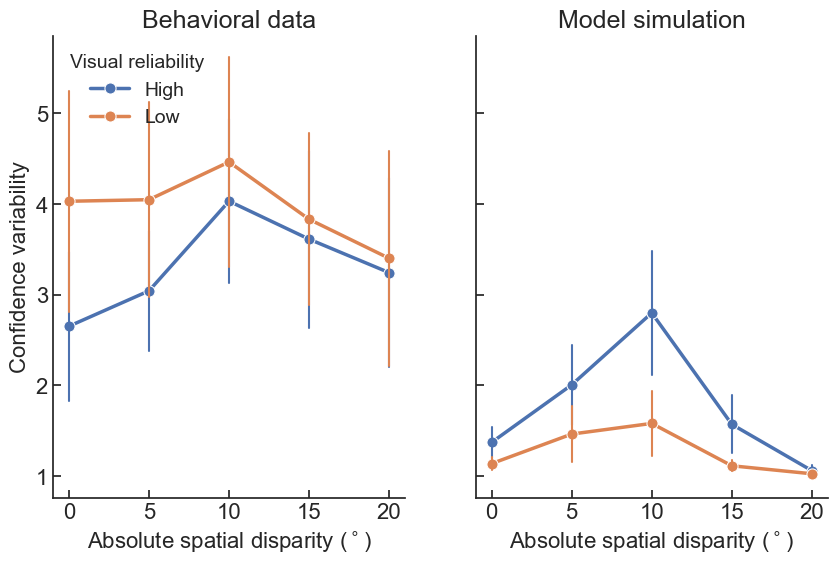

In [85]:
fig, axs = plt.subplots(figsize=(10,6), ncols = 2, nrows = 1, sharey=True)
plot_variability(df=df_beh,  var_var='CISize',ax=axs[0], Modality='A', palette= palette_beh)
plot_variability(df=df_sim, var_var='CISize', m_id=2, ax=axs[1], Modality='A', palette= palette_beh)
axs[0].set_ylabel('Confidence variability', fontsize=fontsize)
axs[0].set_title('Behavioral data', fontsize=fontsize+2)
axs[1].set_title('Model simulation', fontsize=fontsize+2)
axs[1].get_legend().remove()

Text(0, 0.5, 'Confidence variability ($^\\circ$)')

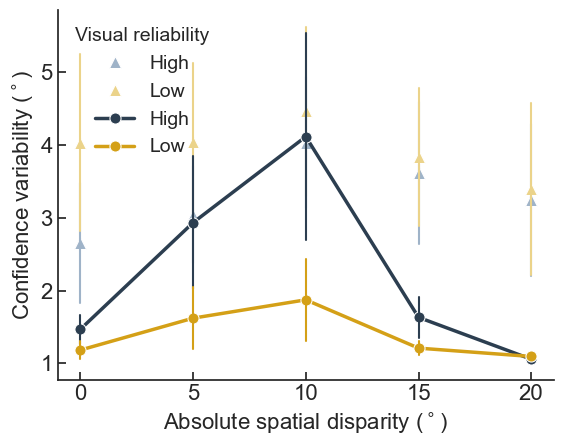

In [17]:
plot_variability(df=df_beh, var_var='CISize', Modality='A',linestyle='',marker='^', palette= {'High': '#9FB3C8', 'Low': '#EBD38A'})
plot_variability(df=df_sim, var_var='CISize', m_id=2, Modality='A', palette= {'High': '#2C3E50', 'Low': '#D4A017'})
plt.ylabel('Confidence variability ($^\\circ$)', fontsize=fontsize)

## bias and confidence

In [68]:
# to-do: combine the std and mean
def plot_mean(df,palette, ax, var_name='bias_abs_zscore', m_id=None, Modality='A', linestyle='-',marker='o'):
    
    if m_id is not None:
        #model simulation data
        df = df.loc[(df.m_id == m_id) & (df.Modality == Modality)].copy()
    else:
        #beh data
        df = df.loc[(df.Modality == Modality)].copy()

    df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc'])[var_name].mean().reset_index()
    df_plot = df_plot.groupby(['sub_id', 'VisRelLabel', 'AudLoc'])[var_name].mean().reset_index()
    #palette = sns.color_palette("viridis", as_cmap=False)

    sns.lineplot(
        data=df_plot,
        x='AudLoc',
        y=var_name,
        hue='VisRelLabel',
        hue_order=['High', 'Low'],  
        palette=palette ,
        linewidth=2.5,
        ax = ax,
        #legend = None,
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
        linestyle=linestyle,
        marker=marker ,
        #capsize=0.2 
        markersize=8
    )

    clean_axs(ax)
    ax.set_xlabel('')
    #set x and y labels
    #ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)
    #ax.set_ylabel('Confidence interval mean z-scored ($^\\circ$)', fontsize=fontsize)
    ax.legend(
        title='Visual reliability',
        frameon=False,
        loc='best',
        fontsize=fontsize-2,
        title_fontsize=fontsize-2
    )

In [7]:
def plot_mean_var(df,palette, ax, stat_var = 'mean', var_name='bias_abs', m_id=None, Modality='A', linestyle='-',marker='o'):
    
    if m_id is not None:
        #model simulation data
        df = df.loc[(df.m_id == m_id) & (df.Modality == Modality)].copy()
    else:
        #beh data
        df = df.loc[(df.Modality == Modality)].copy()

    df_plot = df.groupby(['sub_id', 'VisRelLabel', 'abs_delta_VA', 'AudLoc'])[var_name].agg(['mean', 'var']).reset_index()
    df_plot = df_plot.groupby(['sub_id', 'VisRelLabel', 'AudLoc'])[stat_var].mean().reset_index()
    #palette = sns.color_palette("viridis", as_cmap=False)

    sns.lineplot(
        data=df_plot,
        x='AudLoc',
        y=stat_var,
        hue='VisRelLabel',
        hue_order=['High', 'Low'],  
        palette=palette ,
        linewidth=2.5,
        ax = ax,
        #legend = None,
        estimator = 'mean',
        errorbar='se',
        err_style='bars',
        linestyle=linestyle,
        marker=marker ,
        #capsize=0.2 
        markersize=8
    )

    clean_axs(ax)
    ax.set_xlabel('')
    #set x and y labels
    #ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)
    #ax.set_ylabel('Confidence interval mean z-scored ($^\\circ$)', fontsize=fontsize)
    ax.legend(
        title='Visual reliability',
        frameon=False,
        loc='best',
        fontsize=fontsize-2,
        title_fontsize=fontsize-2
    )

Text(0.02, 0.5, 'Absolute Bias ($^\\circ$)')

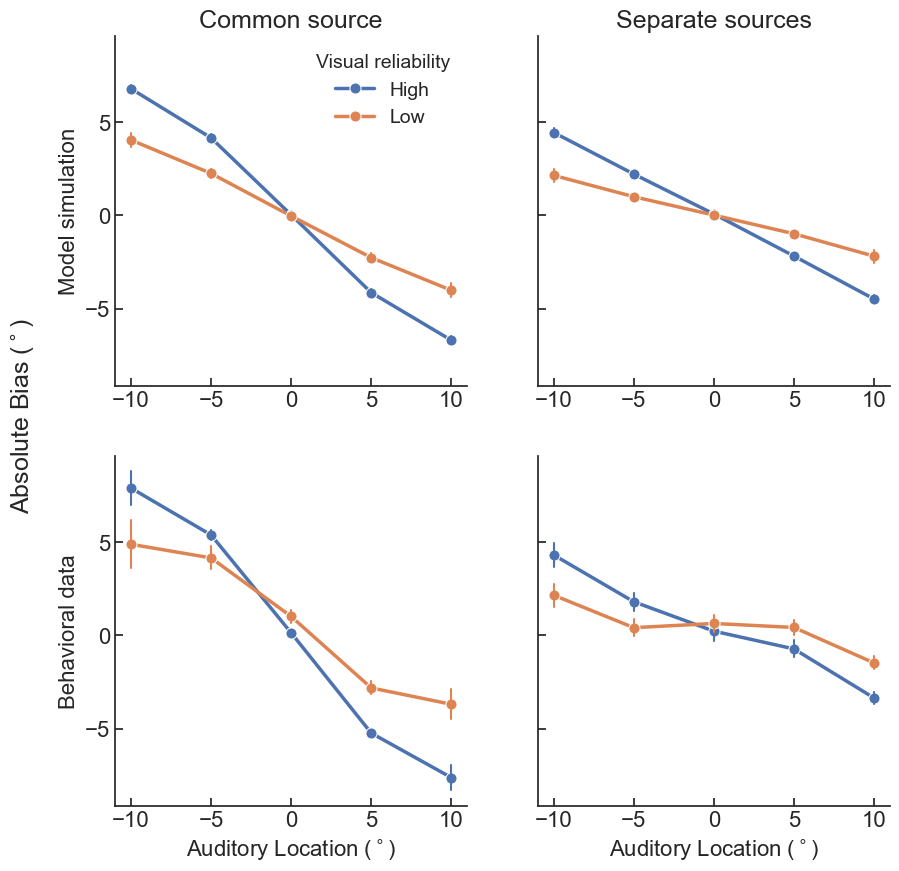

In [33]:
fig, axs = plt.subplots(figsize = (10, 10), nrows=2, ncols=2, sharey=True)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 1], ax = axs[0,0], var_name='bias_abs', Modality='A', palette= palette_beh)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 2], ax = axs[0,1], var_name='bias_abs', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 1], ax = axs[1,0], var_name='bias_abs', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 2], ax = axs[1,1], var_name='bias_abs', Modality='A', palette= palette_beh)
#plot_mean(df=df_sim, var_name='bias_abs_zscore', m_id=2, Modality='A', palette= {'High': '#2C3E50', 'Low': '#D4A017'}, ax=axs[1])
axs[0,0].set_ylabel('Model simulation', fontsize=fontsize)
axs[0,0].set_title('Common source', fontsize=fontsize+2)
axs[0,1].set_title('Separate sources', fontsize=fontsize+2)
axs[1,0].set_ylabel('Behavioral data', fontsize=fontsize)
for ax in axs[1,:]:
    ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)

for ax in [axs[1,0], axs[0,1], axs[1,1]]:
    ax.get_legend().remove()
fig.supylabel('Absolute Bias ($^\\circ$)', fontsize=fontsize+2)


Text(0.02, 0.5, 'Localization variability')

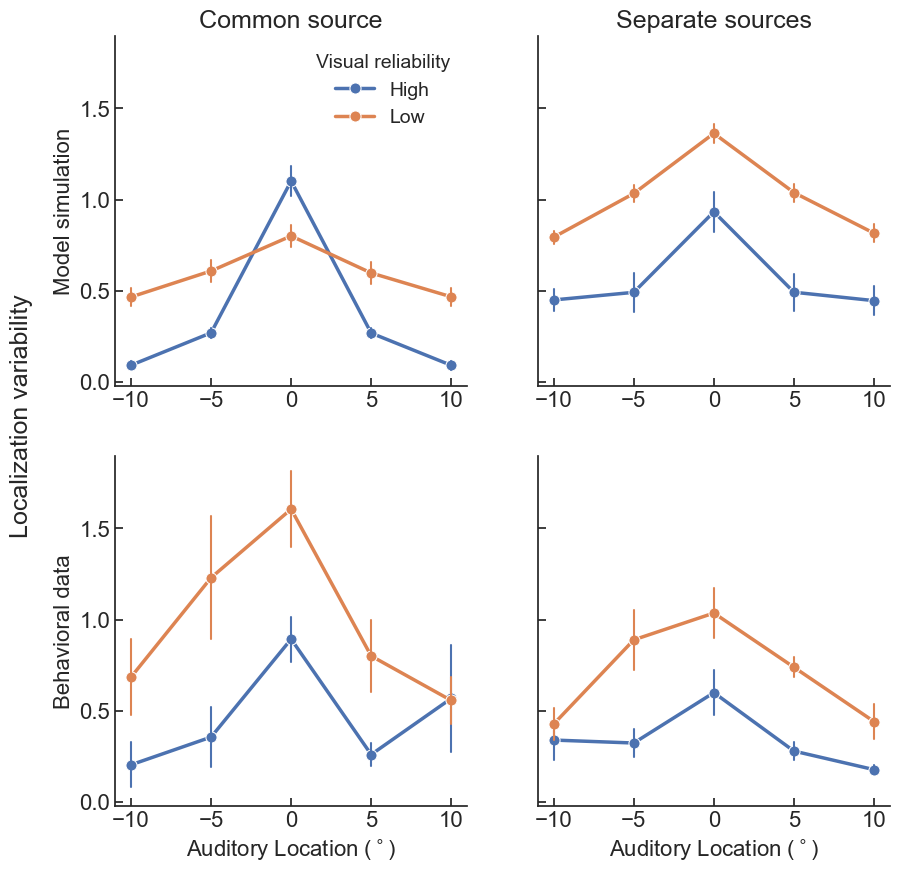

In [ ]:
fig, axs = plt.subplots(figsize = (10, 10), nrows=2, ncols=2, sharey=True)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 1], stat_var='var', ax = axs[0,0], var_name='bias_abs_zscore', Modality='A', palette= palette_beh)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 2], stat_var='var', ax = axs[0,1], var_name='bias_abs_zscore', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 1], stat_var='var', ax = axs[1,0], var_name='bias_abs_zscore', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 2], stat_var='var', ax = axs[1,1], var_name='bias_abs_zscore', Modality='A', palette= palette_beh)
axs[0,0].set_ylabel('Model simulation', fontsize=fontsize)
axs[0,0].set_title('Common source', fontsize=fontsize+2)
axs[0,1].set_title('Separate sources', fontsize=fontsize+2)
axs[1,0].set_ylabel('Behavioral data', fontsize=fontsize)
for ax in axs[1,:]:
    ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)

for ax in [axs[1,0], axs[0,1], axs[1,1]]:
    ax.get_legend().remove()
fig.supylabel('Localization variability', fontsize=fontsize+2)


Text(0.5, 0.98, 'Behavioral data')

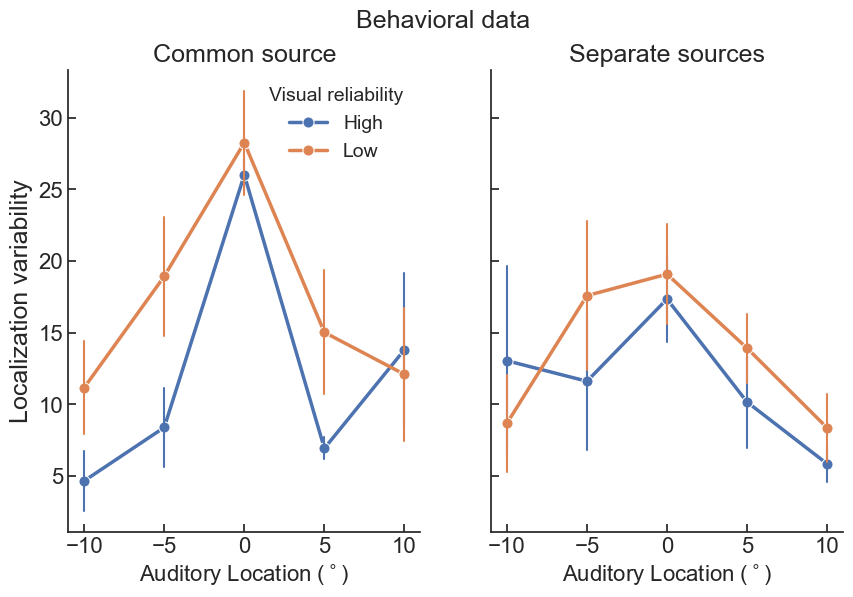

In [24]:
fig, axs = plt.subplots(figsize = (10, 6), nrows=1, ncols=2, sharey=True)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 1], stat_var='var', ax = axs[0], var_name='RespLoc', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 2], stat_var='var', ax = axs[1], var_name='RespLoc', Modality='A', palette= palette_beh)
axs[0].set_title('Common source', fontsize=fontsize+2)
axs[1].set_title('Separate sources', fontsize=fontsize+2)
axs[1].get_legend().remove()
for ax in axs:
    ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)

axs[0].set_ylabel('Localization variability', fontsize=fontsize+2)
fig.suptitle('Behavioral data', fontsize=fontsize+2)

Text(0, 0.5, 'Localization variability')

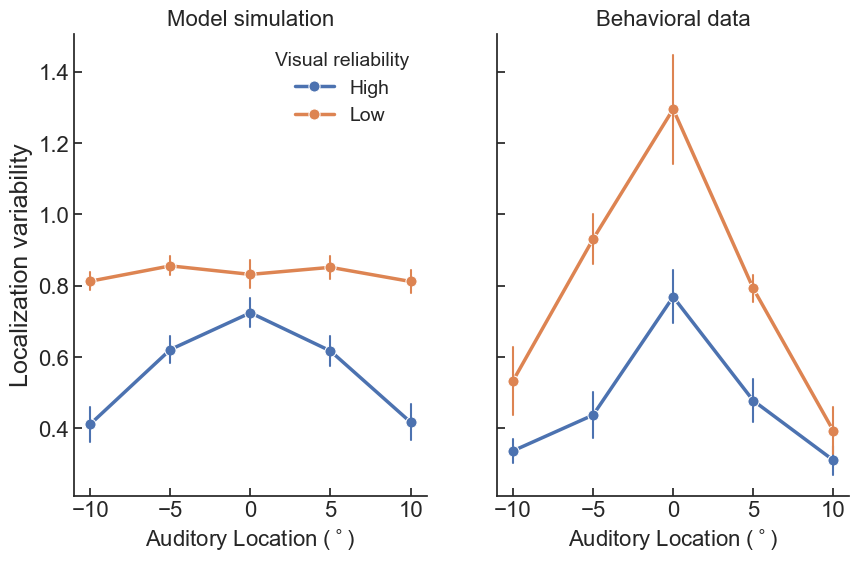

In [21]:
fig, axs = plt.subplots(figsize = (10, 6), nrows=1, ncols=2, sharey=True)
plot_mean_var(df=df_sim, stat_var='var', ax = axs[0], var_name='bias_abs_zscore', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh, stat_var='var', ax = axs[1], var_name='bias_abs_zscore', Modality='A', palette= palette_beh)
axs[0].set_title('Model simulation', fontsize=fontsize)
axs[1].set_title('Behavioral data', fontsize=fontsize)
for ax in axs:
    ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)

axs[1].get_legend().remove()
axs[0].set_ylabel('Localization variability', fontsize=fontsize+2)

Text(0.01, 0.5, 'Confidence interval size ($^\\circ$)')

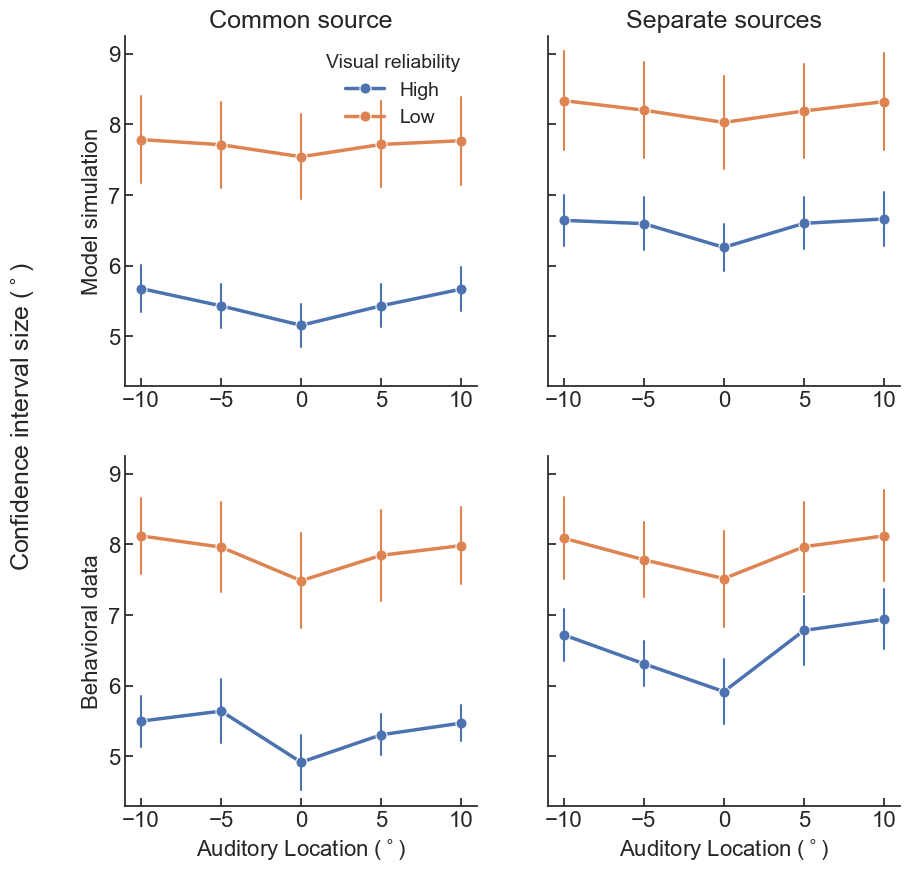

In [34]:
fig, axs = plt.subplots(figsize = (10, 10), nrows=2, ncols=2, sharey=True)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 1], stat_var = 'mean', ax = axs[0,0], var_name='CISize', Modality='A', palette= palette_beh)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 2], stat_var = 'mean', ax = axs[0,1], var_name='CISize', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 1], stat_var = 'mean', ax = axs[1,0], var_name='CISize', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 2], stat_var = 'mean', ax = axs[1,1], var_name='CISize', Modality='A', palette= palette_beh)
#plot_mean(df=df_sim, var_name='CISize_zscore', m_id=2, Modality='A', palette= {'High': '#2C3E50', 'Low': '#D4A017'}, ax=axs[1])
axs[0,0].set_ylabel('Model simulation', fontsize=fontsize)
axs[0,0].set_title('Common source', fontsize=fontsize+2)
axs[0,1].set_title('Separate sources', fontsize=fontsize+2)
axs[1,0].set_ylabel('Behavioral data', fontsize=fontsize)
for ax in axs[1,:]:
    ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)
    ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)
for ax in [axs[1,0], axs[0,1], axs[1,1]]:
    ax.get_legend().remove()
fig.supylabel(
    'Confidence interval size ($^\circ$)',
    fontsize=fontsize+2,
    x=0.01  # smaller values move it further left
)


Text(0.5, 0.98, 'Behavioral data')

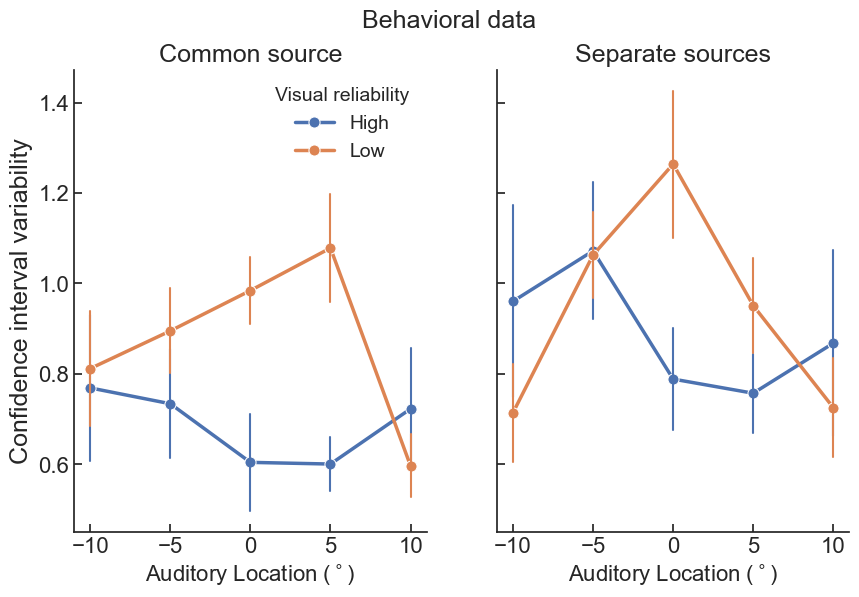

In [26]:
fig, axs = plt.subplots(figsize = (10, 6), nrows=1, ncols=2, sharey=True)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 1], stat_var='var', ax = axs[0], var_name='CISize_zscore', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 2], stat_var='var', ax = axs[1], var_name='CISize_zscore', Modality='A', palette= palette_beh)
axs[0].set_title('Common source', fontsize=fontsize+2)
axs[1].set_title('Separate sources', fontsize=fontsize+2)
axs[1].get_legend().remove()
for ax in axs:
    ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)

axs[0].set_ylabel('Confidence interval variability', fontsize=fontsize+2)
fig.suptitle('Behavioral data', fontsize=fontsize+2)

Text(0, 0.5, 'Confidence interval variability')

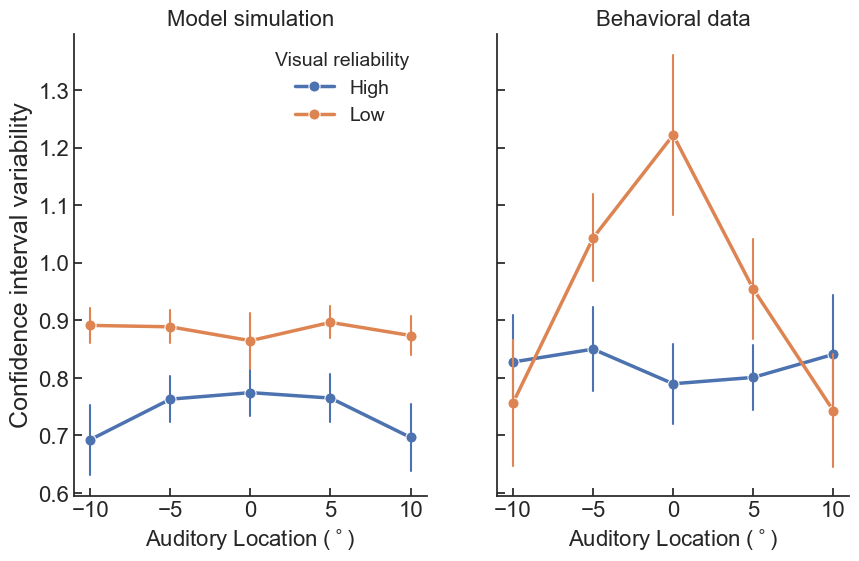

In [22]:
fig, axs = plt.subplots(figsize = (10, 6), nrows=1, ncols=2, sharey=True)
plot_mean_var(df=df_sim, stat_var='var', ax = axs[0], var_name='CISize_zscore', Modality='A', palette= palette_beh)
plot_mean_var(df=df_beh, stat_var='var', ax = axs[1], var_name='CISize_zscore', Modality='A', palette= palette_beh)
axs[0].set_title('Model simulation', fontsize=fontsize)
axs[1].set_title('Behavioral data', fontsize=fontsize)
for ax in axs:
    ax.set_xlabel('Auditory Location ($^\\circ$)', fontsize=fontsize)

axs[1].get_legend().remove()
axs[0].set_ylabel('Confidence interval variability', fontsize=fontsize+2)

Text(0.5, 0.98, 'Visual modality')

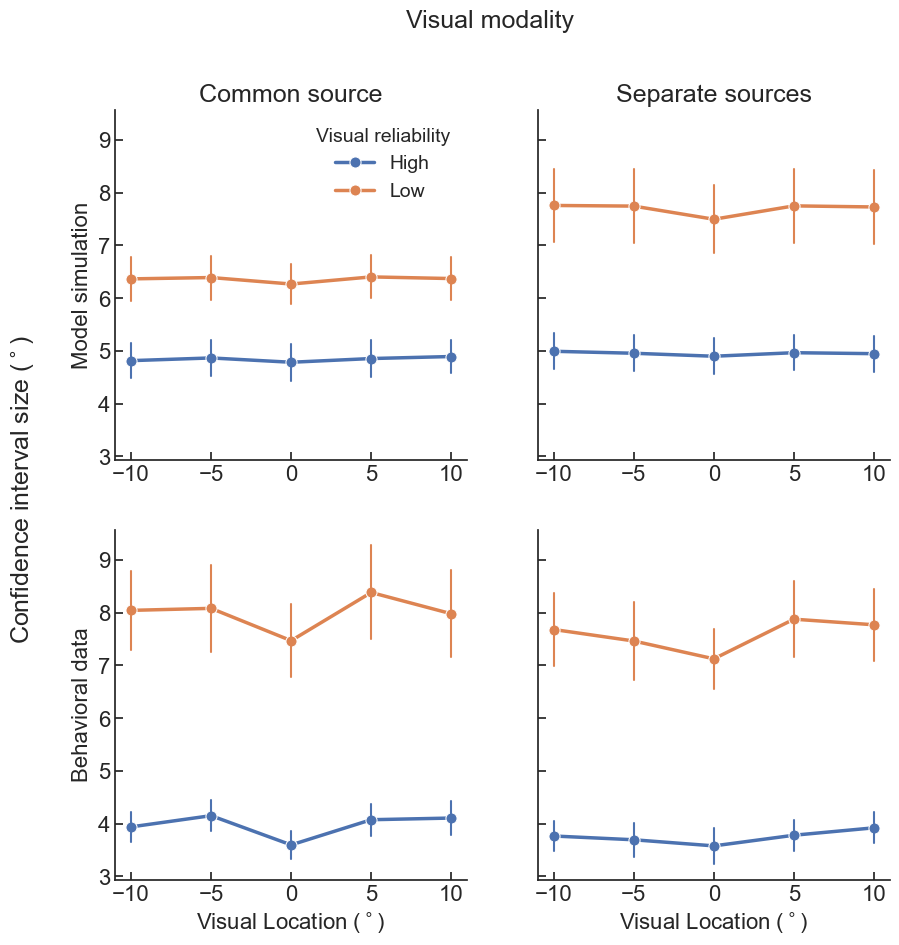

In [20]:
fig, axs = plt.subplots(figsize = (10, 10), nrows=2, ncols=2, sharey=True)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 1], ax = axs[0,0], var_name='CISize', Modality='V', palette= palette_beh)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 2], ax = axs[0,1], var_name='CISize', Modality='V', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 1], ax = axs[1,0], var_name='CISize', Modality='V', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 2], ax = axs[1,1], var_name='CISize', Modality='V', palette= palette_beh)
#plot_mean(df=df_sim, var_name='CISize_zscore', m_id=2, Modality='A', palette= {'High': '#2C3E50', 'Low': '#D4A017'}, ax=axs[1])
axs[0,0].set_ylabel('Model simulation', fontsize=fontsize)
axs[0,0].set_title('Common source', fontsize=fontsize+2)
axs[0,1].set_title('Separate sources', fontsize=fontsize+2)
axs[1,0].set_ylabel('Behavioral data', fontsize=fontsize)
for ax in axs[1,:]:
    ax.set_xlabel('Visual Location ($^\\circ$)', fontsize=fontsize)
    ax.set_xlabel('Visual Location ($^\\circ$)', fontsize=fontsize)
for ax in [axs[1,0], axs[0,1], axs[1,1]]:
    ax.get_legend().remove()
fig.supylabel('Confidence interval size ($^\\circ$)', fontsize=fontsize+2)
fig.suptitle('Visual modality', fontsize=fontsize+2)

Text(0.5, 0.98, 'Visual modality')

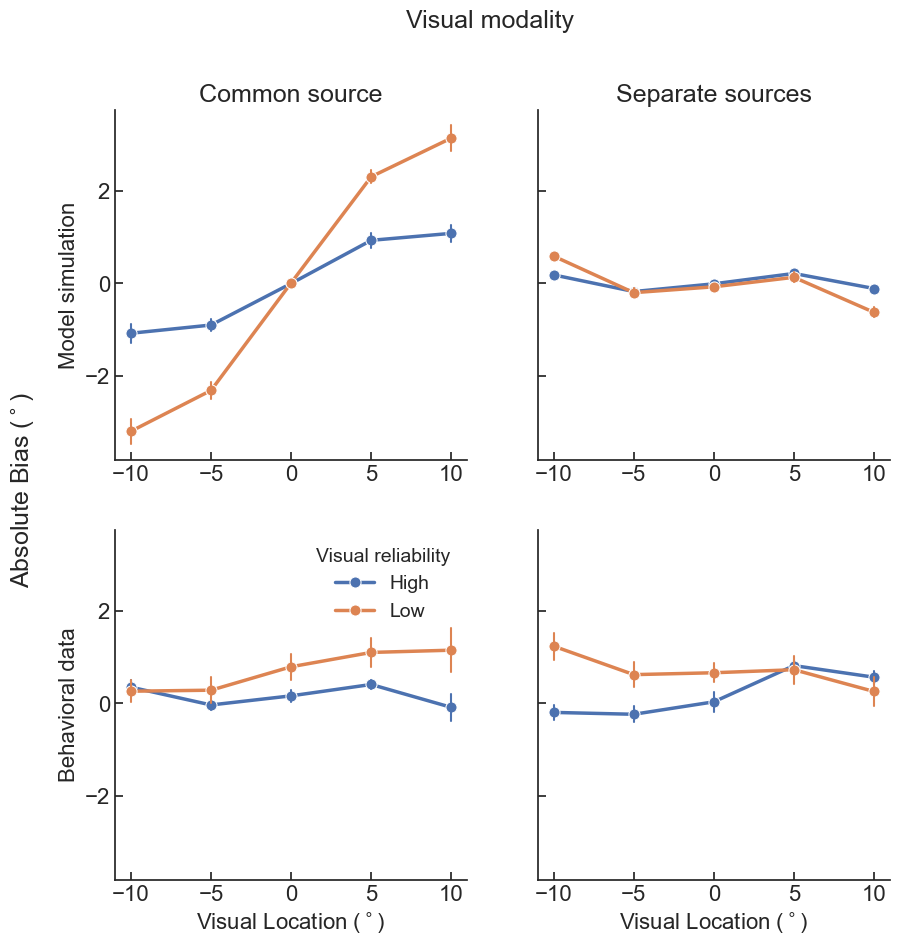

In [10]:
fig, axs = plt.subplots(figsize = (10, 10), nrows=2, ncols=2, sharey=True)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 1], ax = axs[0,0], var_name='bias_abs', Modality='V', palette= palette_beh)
plot_mean_var(df=df_sim.loc[df_sim.Sources == 2], ax = axs[0,1], var_name='bias_abs', Modality='V', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 1], ax = axs[1,0], var_name='bias_abs', Modality='V', palette= palette_beh)
plot_mean_var(df=df_beh.loc[df_beh.Sources == 2], ax = axs[1,1], var_name='bias_abs', Modality='V', palette= palette_beh)
#plot_mean_var(df=df_sim, var_name='bias_abs_zscore', m_id=2, Modality='A', palette= {'High': '#2C3E50', 'Low': '#D4A017'}, ax=axs[1])
axs[0,0].set_ylabel('Model simulation', fontsize=fontsize)
axs[0,0].set_title('Common source', fontsize=fontsize+2)
axs[0,1].set_title('Separate sources', fontsize=fontsize+2)
axs[1,0].set_ylabel('Behavioral data', fontsize=fontsize)
for ax in axs[1,:]:
    ax.set_xlabel('Visual Location ($^\\circ$)', fontsize=fontsize)
    ax.set_xlabel('Visual Location ($^\\circ$)', fontsize=fontsize)
for ax in [axs[0,0], axs[0,1], axs[1,1]]:
    ax.get_legend().remove()
fig.supylabel('Absolute Bias ($^\\circ$)', fontsize=fontsize+2)
fig.suptitle('Visual modality', fontsize=fontsize+2)

## Causal inference

Text(0.02, 0.5, 'Causal confidence (0-100)')

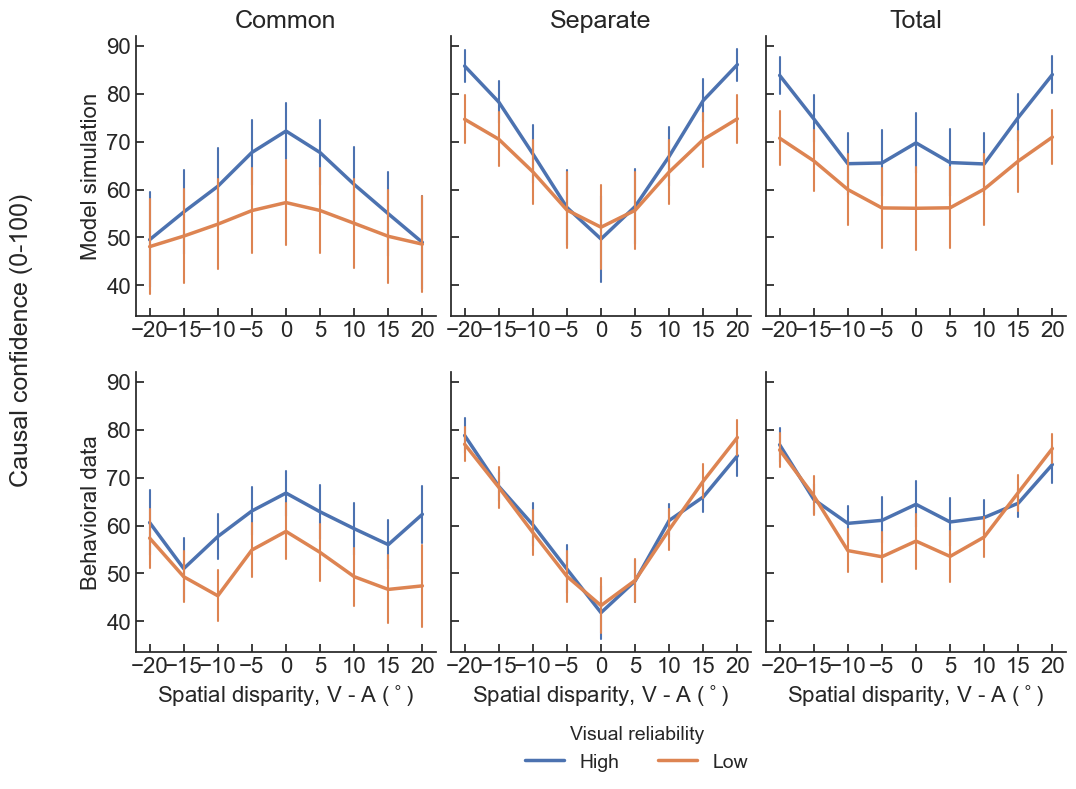

In [35]:
fig, axs = plt.subplots(figsize=(12, 8), ncols=3, nrows=2, sharey=True,
                        gridspec_kw={'wspace': 0.05, 'hspace': 0.2})
plot_casual_conf(df=df_sim.loc[df_sim.m_id==m_id], palette=palette_beh, com_label='Common', ax=axs[0,0])
plot_casual_conf(df=df_sim.loc[df_sim.m_id==m_id], palette=palette_beh, com_label='Total', ax=axs[0,2])
plot_casual_conf(df=df_sim.loc[df_sim.m_id==m_id], palette=palette_beh, com_label='Separate', ax=axs[0,1])
plot_casual_conf(df=df_beh, palette=palette_beh, com_label='Common', ax=axs[1,0])
plot_casual_conf(df=df_beh, palette=palette_beh, com_label='Total', ax=axs[1,2], leg='auto')
plot_casual_conf(df=df_beh, palette=palette_beh, com_label='Separate', ax=axs[1,1])
for ax in axs[0,:]:
    ax.set_xlabel('')
axs[0,2].set_title('Total', fontsize=fontsize+2)
axs[0,0].set_title('Common', fontsize=fontsize+2)   
axs[0,1].set_title('Separate', fontsize=fontsize+2)
axs[0,0].set_ylabel('Model simulation', fontsize=fontsize)
axs[1,0].set_ylabel('Behavioral data', fontsize=fontsize)
fig.supylabel('Causal confidence (0-100)', fontsize=fontsize+2)

Text(0.02, 0.5, 'Causal confidence (0-100)')

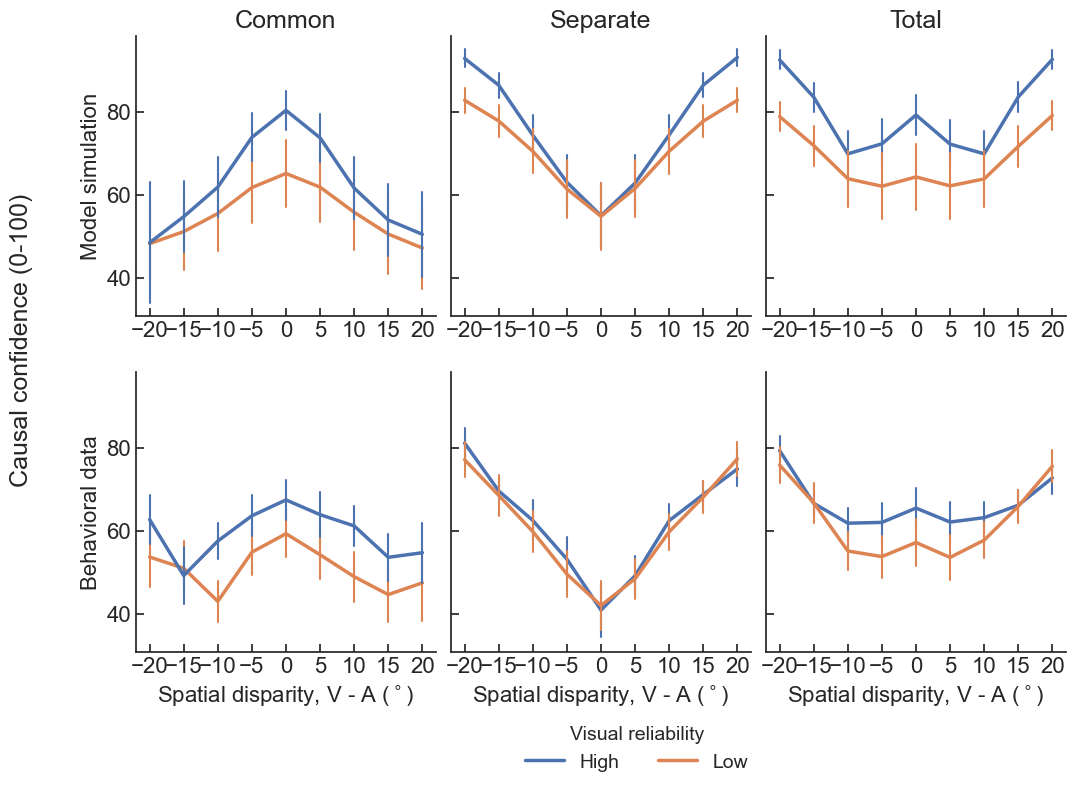

In [16]:
fig, axs = plt.subplots(figsize=(12, 8), ncols=3, nrows=2, sharey=True,
                        gridspec_kw={'wspace': 0.05, 'hspace': 0.2})
plot_group_pattern(df=df_sim.loc[df_sim.m_id==m_id], yvar='ConfLevel', palette=palette_beh, com_label='Common', ax=axs[0,0], trial_type='A')
plot_group_pattern(df=df_sim.loc[df_sim.m_id==m_id], yvar='ConfLevel', palette=palette_beh, com_label='Total', ax=axs[0,2], trial_type='A')
plot_group_pattern(df=df_sim.loc[df_sim.m_id==m_id], yvar='ConfLevel', palette=palette_beh, com_label='Separate', ax=axs[0,1], trial_type='A')
plot_group_pattern(df=df_beh, yvar='ConfLevel', palette=palette_beh, com_label='Common', ax=axs[1,0])
plot_group_pattern(df=df_beh, yvar='ConfLevel', palette=palette_beh, com_label='Total', ax=axs[1,2], leg='auto')
plot_group_pattern(df=df_beh, yvar='ConfLevel', palette=palette_beh, com_label='Separate', ax=axs[1,1])
for ax in axs[0,:]:
    ax.set_xlabel('')
axs[0,2].set_title('Total', fontsize=fontsize+2)
axs[0,0].set_title('Common', fontsize=fontsize+2)   
axs[0,1].set_title('Separate', fontsize=fontsize+2)
axs[0,0].set_ylabel('Model simulation', fontsize=fontsize)
axs[1,0].set_ylabel('Behavioral data', fontsize=fontsize)
fig.supylabel('Causal confidence (0-100)', fontsize=fontsize+2)

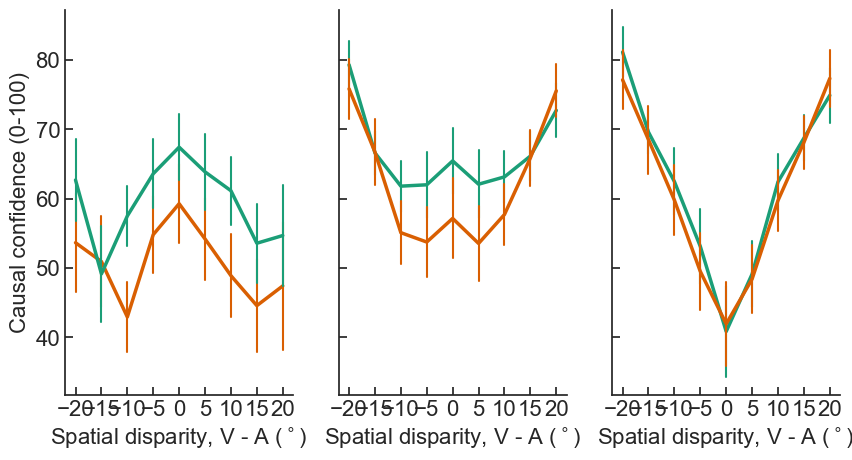

In [75]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=3, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
plot_group_pattern(df_beh, 'ConfLevel', 'Common', axs[0])
plot_group_pattern(df_beh, 'ConfLevel', 'Total', axs[1])
plot_group_pattern(df_beh, 'ConfLevel', 'Separate', axs[2])

### Correlations between causal and perceptual confidence.

### Formal model comparison

In [21]:
exp_name1, exp_name2 = 'test_causal_bin1', 'with_dn'
CM=CompareModels(exp_name1, exp_name2)
m_lst= [2]

In [22]:
df_ev, df_best_model = CM.compare_models(m1_list=m_lst, m2_list=m_lst, best_by='BIC', by_nll='train')

In [23]:
df_ev

,m_id,exp,sub_id,AIC,AICc,BIC,nll,npar,best_par,nll_method,CI_readout,est_var,Causal_readout
0,2,test_causal_bin1,2,37568.566724,37568.738785,37649.854774,18770.283362,14,"[1.326134351452349, 4.650853633880615, 4.64873...",QML,BayInt,MS,Bay
1,2,test_causal_bin1,3,35324.544129,35324.719202,35405.590695,17648.272065,14,"[1.0045600873260956, 3.6532156467437744, 5.579...",QML,BayInt,MS,Bay
2,2,test_causal_bin1,5,35605.052149,35605.226930,35686.121893,17788.526074,14,"[1.7991667350174971, 4.258444547653198, 3.9422...",QML,BayInt,MS,Bay
3,2,test_causal_bin1,6,34258.787898,34258.962680,34339.857643,17115.393949,14,"[1.4439854756012767, 1.755759835243225, 3.3877...",QML,BayInt,MS,Bay
4,2,test_causal_bin1,11,35646.966846,35647.141409,35728.053949,17809.483423,14,"[1.079057272269894, 3.7007843255996704, 4.2345...",QML,BayInt,MS,Bay
5,2,test_causal_bin1,15,38115.504884,38115.676733,38196.810024,19043.752442,14,"[0.5902048433094178, 6.306135773658752, 6.2475...",QML,BayInt,MS,Bay
6,2,test_causal_bin1,20,34270.218675,34270.394775,34351.183811,17121.109337,14,"[0.9323276798160927, 2.7525576651096344, 5.001...",QML,BayInt,MS,Bay
7,2,test_causal_bin1,25,39009.191750,39009.364518,39090.422680,19490.595875,14,"[0.45784243104317845, 1.666839599609375, 4.490...",QML,BayInt,MS,Bay
8,2,with_dn,2,35779.248434,35779.445155,35866.342773,17874.624217,15,"[2.021700377847035, 6.817628875374794, 5.20707...",QML,BayInt,MS,Bay
9,2,with_dn,3,35409.843480,35410.043647,35496.679086,17689.921740,15,"[3.508105432502043, 6.77004337310791, 5.177550...",QML,BayInt,MS,Bay


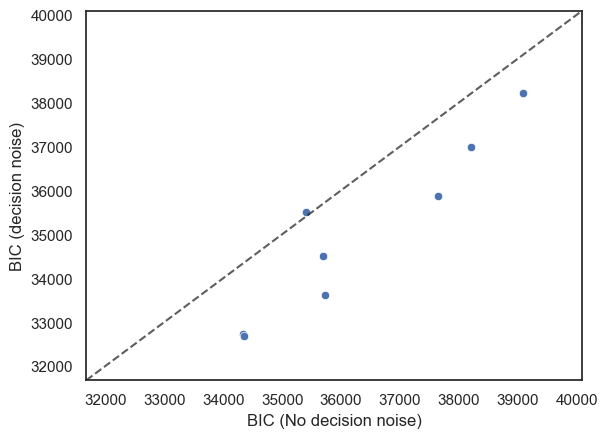

In [25]:
# two models comparison plot BIC aganist BIC
sns.scatterplot(x=df_ev.loc[(df_ev.m_id==m_lst[0]) & (df_ev.exp==exp_name1), 'BIC'].reset_index(drop=True), y=df_ev.loc[(df_ev.m_id==m_lst[0]) & (df_ev.exp==exp_name2), 'BIC'].reset_index(drop=True))
lims = [
    df_ev.BIC.min()-1000,  # lowest value across both
    df_ev.BIC.max()+1000   # highest value across both
]
plt.xlim(lims)
plt.ylim(lims)

# Add diagonal y=x line
plt.plot(lims, lims, 'k--', alpha=0.7)

plt.xlabel("BIC (No decision noise)")
plt.ylabel("BIC (decision noise)")

plt.show()